# Consip Consumi Convenzione 2023-2025 — validazione dati

Notebook tecnico. Genera le figure per il README.

**Dataset**: `consip_consumi_convenzione` (Consip/MEF) via GCS clean parquet.
**Serie**: 2023-2025, tipologie PA, regioni, convenzioni.

Per la narrativa completa vedi il [README](../README.md).


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

pd.options.display.float_format = '{:,.0f}'.format
plt.rcParams['figure.dpi'] = 150

con = duckdb.connect()
con.execute('INSTALL httpfs; LOAD httpfs;')

GCS = 'gs://dataciviclab-clean/consip_consumi_convenzione/*/consip_consumi_convenzione_*_clean.parquet'

anni = con.execute(f"SELECT DISTINCT anno_riferimento FROM read_parquet('{GCS}') ORDER BY 1").fetchdf()
print(f"Anni: {list(anni['anno_riferimento'])}")

Anni: [2023, 2024, 2025]


In [2]:
# 1. Trend nazionale 2023-2025
trend = con.execute(f"""
    SELECT anno_riferimento AS anno,
           CAST(SUM(valore_economico_consumi)/1e6 AS INTEGER) AS spesa_M
    FROM read_parquet('{GCS}')
    GROUP BY anno_riferimento
    ORDER BY anno_riferimento
""").fetchdf()

display(trend)

delta = trend[trend['anno']==2025]['spesa_M'].values[0] - trend[trend['anno']==2023]['spesa_M'].values[0]
print(f"Delta 2023-2025: {delta}M ({delta/trend[trend['anno']==2023]['spesa_M'].values[0]*100:.0f}%)")

,anno,spesa_M
0,2023,3626
1,2024,3077
2,2025,3062


Delta 2023-2025: -564M (-16%)


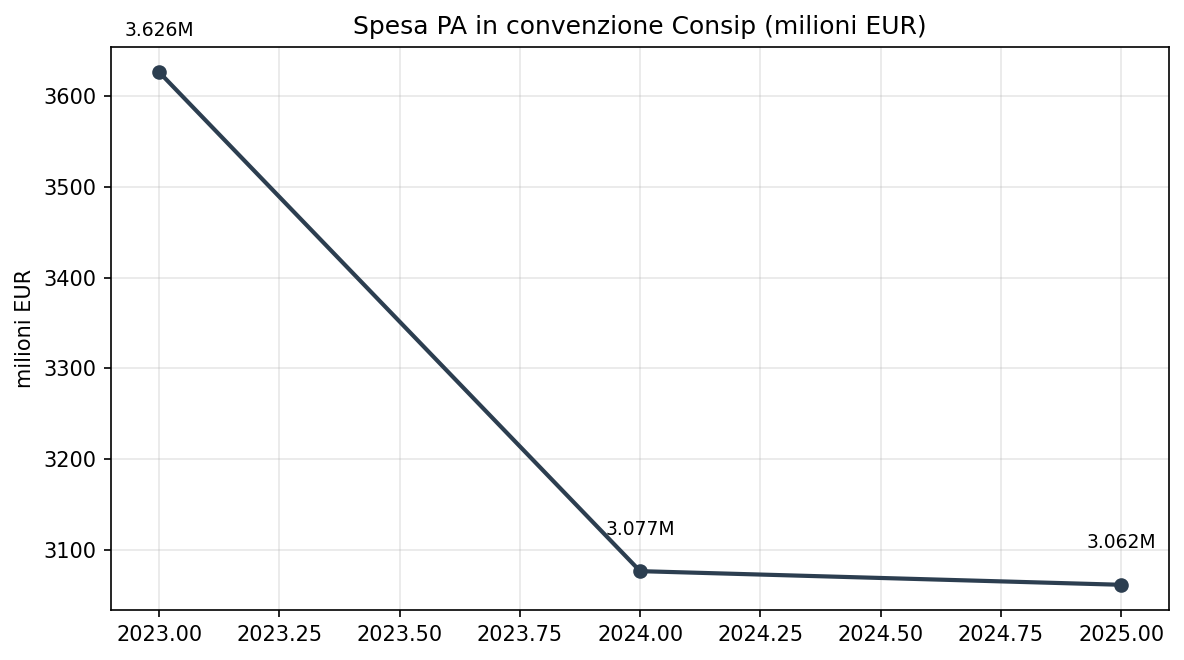

Salvato: figures/consip_trend.png


In [3]:
# Grafico trend
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(trend['anno'], trend['spesa_M'], marker='o', linewidth=2, color='#2c3e50')
ax.set_title('Spesa PA in convenzione Consip (milioni EUR)', fontsize=12)
ax.set_ylabel('milioni EUR')
ax.grid(alpha=0.3)

for _, r in trend.iterrows():
    ax.text(r['anno'], r['spesa_M'] + 40, f"{r['spesa_M']:,}M".replace(',', '.'), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/consip_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/consip_trend.png')

In [4]:
# 2. Spesa per settore (2024)
settori = con.execute(f"""
    SELECT CASE
        WHEN convenzione LIKE 'ENERGIA ELETTRICA%' THEN 'Energia elettrica'
        WHEN convenzione LIKE 'GAS NATURALE%' THEN 'Gas naturale'
        WHEN convenzione LIKE 'CARBURANTI%' THEN 'Carburanti'
        ELSE 'Altro'
    END AS settore,
    CAST(SUM(valore_economico_consumi)/1e6 AS INTEGER) AS spesa_M
    FROM read_parquet('{GCS}')
    WHERE anno_riferimento = 2024
    GROUP BY 1 ORDER BY spesa_M DESC
""").fetchdf()

display(settori)

tot = settori['spesa_M'].sum()
energia = settori[settori['settore']=='Energia elettrica']['spesa_M'].values[0]
print(f"Energia elettrica: {energia}M su {tot}M totale ({energia*100//tot}%)")

,settore,spesa_M
0,Energia elettrica,2282
1,Gas naturale,512
2,Carburanti,239
3,Altro,44


Energia elettrica: 2282M su 3077M totale (74%)


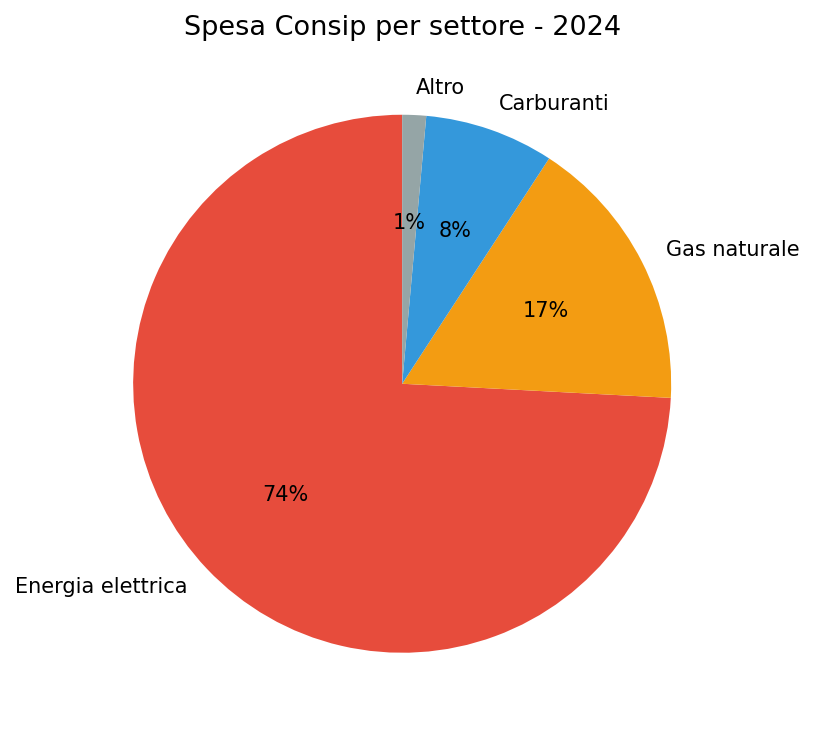

Salvato: figures/consip_settori.png


In [5]:
# Grafico a torta settori
fig, ax = plt.subplots(figsize=(8, 5))
colors_settori = ['#e74c3c', '#f39c12', '#3498db', '#95a5a6']
wedges, texts, autotexts = ax.pie(
    settori['spesa_M'], labels=settori['settore'], autopct='%1.0f%%',
    colors=colors_settori, startangle=90)
ax.set_title('Spesa Consip per settore - 2024', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/consip_settori.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/consip_settori.png')

In [6]:
# 3. Tipologie amministrazione (2024)
tipi = con.execute(f"""
    SELECT tipologia_amministrazione,
           CAST(SUM(valore_economico_consumi)/1e6 AS INTEGER) AS spesa_M
    FROM read_parquet('{GCS}')
    WHERE anno_riferimento = 2024
    GROUP BY tipologia_amministrazione
    ORDER BY spesa_M DESC
""").fetchdf()

display(tipi)

print(f"Comuni + Enti territoriali: {tipi.iloc[0:2]['spesa_M'].sum():,}M")
print(f"Quota sul totale: {tipi.iloc[0:2]['spesa_M'].sum()*100//tipi['spesa_M'].sum()}%")

,tipologia_amministrazione,spesa_M
0,COMUNI,768
1,AZIENDE ED ENTI TERRITORIALI DI SERVIZI PUBBLICI,655
2,MINISTERI E AGENZIE FISCALI,509
3,"AZIENDE OSPEDALIERE, POLICLINICI, IRCCS e ISTI...",240
4,AZIENDE SANITARIE LOCALI E PROVINCIALI,182
5,S.P.A. DELLO STATO E SOCIETA' PARTECIPATE STATALI,174
6,UNIVERSITA' E POLITECNICI,165
7,PROVINCE,119
8,ISTITUTI/ENTI DI RICERCA,47
9,"ENTI, ISTITUTI E FONDI PREVIDENZIALI",38


Comuni + Enti territoriali: 1,423M
Quota sul totale: 46%


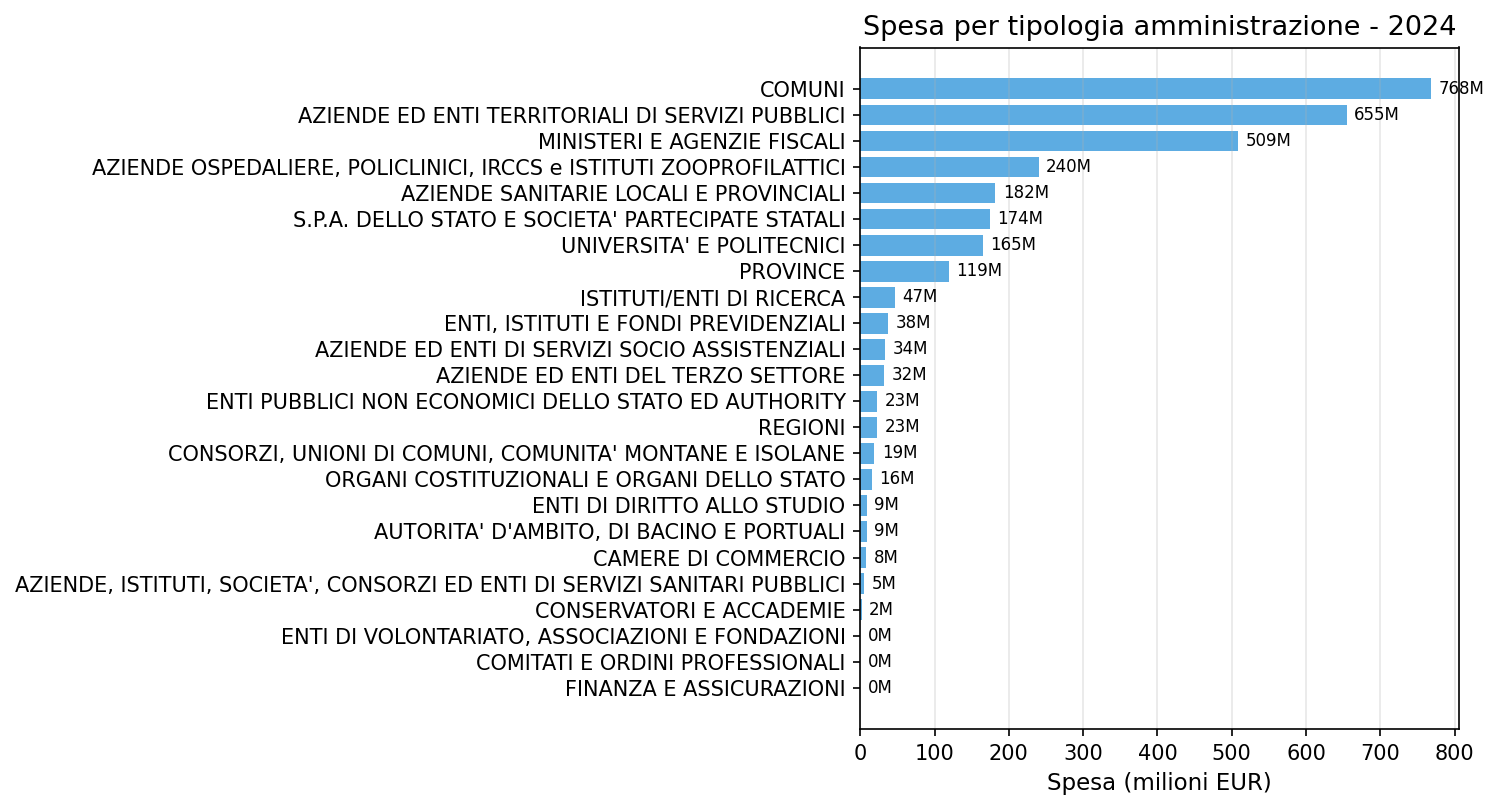

Salvato: figures/consip_tipologie.png


In [7]:
# Grafico tipologie
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_data = tipi.sort_values('spesa_M')
bars = ax.barh(plot_data['tipologia_amministrazione'], plot_data['spesa_M'], color='#3498db', alpha=0.8)
ax.set_xlabel('Spesa (milioni EUR)', fontsize=11)
ax.set_title('Spesa per tipologia amministrazione - 2024', fontsize=13)
ax.grid(alpha=0.3, axis='x')

for bar, val in zip(bars, plot_data['spesa_M']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}M'.replace(',', '.'), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/consip_tipologie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/consip_tipologie.png')

In [8]:
# 4. Regioni PA (2024)
regioni = con.execute(f"""
    SELECT regione_pa AS regione,
           CAST(SUM(valore_economico_consumi)/1e6 AS INTEGER) AS spesa_M
    FROM read_parquet('{GCS}')
    WHERE anno_riferimento = 2024 AND regione_pa IS NOT NULL AND regione_pa != ''
    GROUP BY regione_pa
    ORDER BY spesa_M DESC
""").fetchdf()

display(regioni)

top3 = regioni.head(3)
print(f"Top 3 regioni: {top3['spesa_M'].sum()}M ({top3['spesa_M'].sum()*100//regioni['spesa_M'].sum()}%)")
print(f"Lazio: {regioni.iloc[0]['spesa_M']}M ({regioni.iloc[0]['spesa_M']*100//regioni['spesa_M'].sum()}%)")

,regione,spesa_M
0,LAZIO,615
1,LOMBARDIA,548
2,VENETO,258
3,SICILIA,248
4,CAMPANIA,206
5,PUGLIA,176
6,SARDEGNA,172
7,EMILIA ROMAGNA,147
8,PIEMONTE,134
9,FRIULI VENEZIA GIULIA,95


Top 3 regioni: 1421M (46%)
Lazio: 615M (19%)


In [9]:
con.close()
print('Completato.')

Completato.
